<a href="https://colab.research.google.com/github/marinakamal1/undergrad_ml_assignments/blob/main/04_assignment_regularization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 4: Regularization  

Marina Kamal

**Q1.** Please answer the following questions in your own words.

1. What is the intuition of adding a penalty to mean squared error, that grows in the "size" (absolute or squared value) of the model parameters?
2. How does regularization provide a way of exploring the bias-variance trade-off?
3. What is the difference between LASSO and Ridge regression? How do the answers typically change for the two problems?
4. How do we typically scale variables for use in regularized regression? Why?
5. How is the penalty $\alpha$ typically selected?
6. When conducting cross validation, do you include the penalty term in evaluating the cross validated MSE? Why or why not?

1. The basic idea is that very large coefficients often mean the model is fitting noise or peculiar patterns in the training data rather than capturing the true signal. By adding a penalty for large coefficients, we discourage the model from becoming too complex or overly sensitive to small fluctuations in the data. So instead of only asking, "How well does the model fit the training data?", regularization asks, "How well does it fit the data while also staying reasonably simple?" This helps produce models that generalize better to new data.

2. Regularization lets us control model flexibility. When the penalty is very small, the model is free to use large coefficients and fit the training data closely. That usually gives low bias but high variance, because the model may overfit. As the penalty gets stronger, coefficients are shrunk toward zero. That makes the model simpler and more stable, so variance decreases, but bias increases, because the model may now underfit.So by changing the penalty strength, we can move along the bias-variance trade-off and choose the level that gives the best out-of-sample performance.

3. LASSO and Ridge regression differ in the way they penalize model complexity, which leads to different behaviors in how coefficients are estimated. Ridge regression uses a penalty based on the sum of squared coefficients, while LASSO uses a penalty based on the sum of the absolute values of coefficients. Because the squared penalty in Ridge is smooth and continuous, it shrinks coefficients toward zero but typically does not make them exactly zero. In contrast, the absolute value penalty in LASSO creates a “kink” at zero, which allows it to force some coefficients to become exactly zero. As a result, the two methods tend to produce different types of models. Ridge regression retains all predictors in the model but reduces their magnitudes, leading to a more stable model when predictors are correlated. LASSO, on the other hand, performs variable selection by setting some coefficients exactly equal to zero, resulting in a sparser and more interpretable model. In practice, when predictors are highly correlated, Ridge tends to distribute the effect across multiple variables, while LASSO often selects one variable and excludes the others.

4. We usually standardize predictors so that each variable has mean 0 and standard deviation 1, often using a z-score transformation. We do this because the penalty depends on coefficient size. If variables are on very different scales, then coefficients are not comparable. A predictor measured in huge units might naturally have a tiny coefficient, while a predictor in small units might need a much larger coefficient. Without scaling, the penalty would unfairly affect some variables more than others. Standardizing makes the penalty apply more evenly across predictors.

5. The penalty parameter α is usually chosen by cross-validation. We try many possible values of α , fit the model on training folds, evaluate prediction error on validation folds, and then choose the value that gives the lowest average validation error.

6. No. When evaluating cross-validated MSE, we usually use only the prediction error on the held-out data, not the penalty term. That is because the goal of cross-validation is to estimate how well the model predicts new observations. The penalty is part of the training objective, used to control the fitted coefficients, but it is not part of the actual prediction error we care about on unseen data. So the penalty helps determine the model, but once the model is fit, the validation metric is just the usual MSE on the held-out fold.

**Q2.** This is a case study on regularization.

1. Import the `cars_hw.csv` dataset. Create an `Age` variable for each vehicle. Take `Mileage_Run` and `Age`, and (a) use `PolynomialFeatures` to create a third degree expansion, (b) use `StandardScaler` to $z$-score normalize them.
2. Use your features, run linear regression. What is the sign for the interaction between `Mileage_Run` and `Age`?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(1,3,20)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero?
7. Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign?

In [1]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import PolynomialFeatures, StandardScaler

cars = pd.read_csv("cars_hw.csv")

cars["Age"] = 2024 - cars["Make_Year"]

X_raw = cars[["Mileage_Run", "Age"]]
y = cars["Price"]

poly = PolynomialFeatures(degree=3, include_bias=False)
X_poly = poly.fit_transform(X_raw)

feature_names = poly.get_feature_names_out(["Mileage_Run", "Age"])

scaler = StandardScaler()
X = scaler.fit_transform(X_poly)

In [2]:
from sklearn.linear_model import LinearRegression

linreg = LinearRegression()
linreg.fit(X, y)

linreg_coefs = pd.Series(linreg.coef_, index=feature_names)

interaction_sign = np.sign(linreg_coefs["Mileage_Run Age"])
print(linreg_coefs["Mileage_Run Age"])

-1251592.3408260453


The interaction term between Mileage_Run and Age in the linear regression model is negative, with a coefficient of approximately -1,251,592.34. This indicates that the combined effect of higher mileage and greater vehicle age leads to an additional decrease in price beyond their individual effects. In practical terms, this suggests that cars that are both older and have higher mileage depreciate more sharply when these factors occur together, reflecting a compounding negative impact on vehicle value.

In [3]:
from sklearn.linear_model import LassoCV

alphas = np.logspace(1, 3, 20)

lasso_cv = LassoCV(alphas=alphas, cv=20, max_iter=500000, random_state=0)
lasso_cv.fit(X, y)

lasso_coefs = pd.Series(lasso_cv.coef_, index=feature_names)

print("Best alpha:", lasso_cv.alpha_)

Best alpha: 483.2930238571752


Using LassoCV with 20-fold cross-validation and a grid of α values from 10 to 1000, the optimal penalty parameter was approximately 483.29. This value represents the level of regularization that minimizes the cross-validated mean squared error, balancing model complexity and predictive accuracy. A relatively large α like this indicates that a substantial amount of shrinkage is needed, suggesting that the unregularized model may be overfitting and that many coefficients benefit from being reduced toward zero.

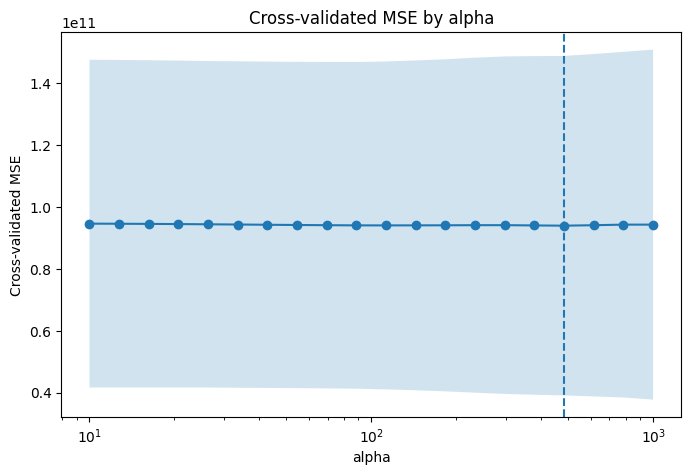

In [4]:
import matplotlib.pyplot as plt

mean_mse = lasso_cv.mse_path_.mean(axis=1)
std_mse = lasso_cv.mse_path_.std(axis=1)

plt.figure(figsize=(8,5))
plt.semilogx(lasso_cv.alphas_, mean_mse, marker='o')
plt.fill_between(lasso_cv.alphas_, mean_mse - std_mse, mean_mse + std_mse, alpha=0.2)
plt.axvline(lasso_cv.alpha_, linestyle='--')
plt.xlabel("alpha")
plt.ylabel("Cross-validated MSE")
plt.title("Cross-validated MSE by alpha")
plt.show()

The cross-validated MSE plot shows that the prediction error remains relatively stable across the range of α values, with only very slight variation. The curve appears fairly flat, indicating that the model’s performance is not highly sensitive to the choice of α within this range. The optimal value of α, approximately 483.29, is selected at the point with the lowest cross-validated MSE, as indicated by the dashed vertical line. This suggests that while regularization is beneficial, there is a broad range of α values that produce similar predictive performance, reflecting a relatively smooth bias-variance trade-off in this model.

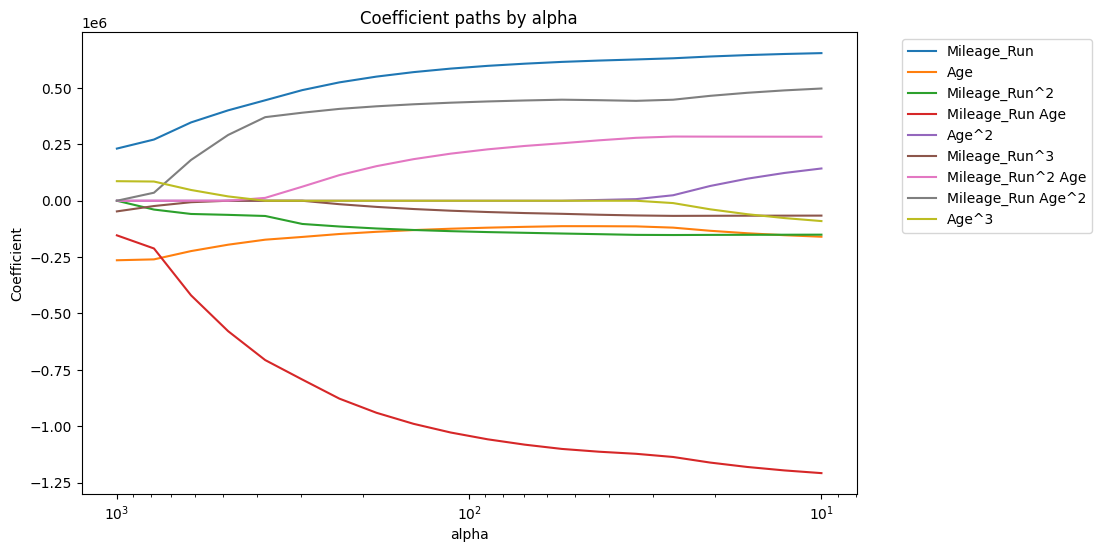

In [7]:
from sklearn.linear_model import lasso_path

alphas_path, coefs_path, _ = lasso_path(X, y, alphas=alphas, max_iter=500000)

plt.figure(figsize=(10,6))
for i, name in enumerate(feature_names):
    plt.semilogx(alphas_path, coefs_path[i], label=name)

plt.gca().invert_xaxis()
plt.xlabel("alpha")
plt.ylabel("Coefficient")
plt.title("Coefficient paths by alpha")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

The coefficient path plot shows how each feature’s coefficient changes as the regularization parameter α varies. As α increases, all coefficients are gradually shrunk toward zero, with some reaching exactly zero at higher levels of regularization. In this plot, features such as Age², Mileage_Run³, and Mileage_Run² × Age shrink to zero relatively early, indicating that they contribute less to the model and are removed by LASSO. In contrast, variables like Mileage_Run, Age, and the Mileage_Run × Age interaction remain nonzero across a wider range of α values, suggesting they are more important predictors of price. Overall, the plot clearly demonstrates how LASSO performs variable selection by progressively eliminating less important features as the penalty increases.

In [5]:
selected = lasso_coefs[lasso_coefs != 0]
zeroed = lasso_coefs[lasso_coefs == 0]

prop_zero = (lasso_coefs == 0).mean()

print("Selected features:")
print(selected)

print("\nProportion set to zero:", prop_zero)

Selected features:
Mileage_Run          401025.259657
Age                 -194803.116695
Mileage_Run^2        -62539.290093
Mileage_Run Age     -578788.661090
Mileage_Run Age^2    292015.025679
Age^3                 19133.908573
dtype: float64

Proportion set to zero: 0.3333333333333333


The features selected by LASSO (those with nonzero coefficients) include Mileage_Run, Age, Mileage_Run², Mileage_Run × Age, Mileage_Run × Age², and Age³. The remaining features, specifically Age², Mileage_Run³, and Mileage_Run² × Age were set equal to zero by the regularization process. This means that 3 out of 9 total polynomial features were eliminated, resulting in a proportion of approximately 0.333 (33.3%) of coefficients being set to zero. This demonstrates that LASSO performs variable selection by removing less important or redundant predictors, leading to a simpler and more interpretable model.

In [6]:
compare = pd.DataFrame({
    "LinearRegression": linreg_coefs,
    "LASSO": lasso_coefs
})

compare["Magnitude_Increased"] = np.abs(compare["LASSO"]) > np.abs(compare["LinearRegression"])
compare["Sign_Changed"] = np.sign(compare["LASSO"]) != np.sign(compare["LinearRegression"])

print(compare)

                   LinearRegression          LASSO  Magnitude_Increased  \
Mileage_Run            6.686165e+05  401025.259657                False   
Age                   -1.841941e+05 -194803.116695                 True   
Mileage_Run^2         -1.494679e+05  -62539.290093                False   
Mileage_Run Age       -1.251592e+06 -578788.661090                False   
Age^2                  2.156399e+05      -0.000000                False   
Mileage_Run^3         -6.514490e+04      -0.000000                False   
Mileage_Run^2 Age      2.833392e+05       0.000000                False   
Mileage_Run Age^2      5.280829e+05  292015.025679                False   
Age^3                 -1.389370e+05   19133.908573                False   

                   Sign_Changed  
Mileage_Run               False  
Age                       False  
Mileage_Run^2             False  
Mileage_Run Age           False  
Age^2                      True  
Mileage_Run^3              True  
Mileage_Run

Comparing the linear regression coefficients to the LASSO coefficients, most coefficients decrease in magnitude under LASSO, which is expected due to the shrinkage effect of regularization. However, the coefficient for Age slightly increases in magnitude (becoming more negative) after regularization, indicating that LASSO can sometimes redistribute weight across predictors when they are correlated. Additionally, several coefficients change sign, including Age², Mileage_Run³, Mileage_Run² × Age, and Age³, with some of these being shrunk to exactly zero. These sign changes occur because LASSO removes unstable or redundant predictors and adjusts the remaining coefficients to better capture the underlying signal. Overall, LASSO produces a simpler and more stable model by shrinking coefficients and eliminating less important features, which helps reduce overfitting and improve interpretability.

**Q3.** This is a case study on regularization.

1. Import the `heart_failure_clinical_records_dataset.csv` dataset. Use `PolynomialFeatures` to create a third-degree expansion of `age`, `ejection_fraction`, and `serum_creatinine`, and then use `StandardScaler` to $z$-score normalize your results. Use `PolynomialFeatures` with `interaction_only=True` to interact the dummy/categorical variables `anaemia`, `diabetes`, `high_blood_pressure`, and `smoking`. Concatenate these results into your feature/covariate matrix.
2. Use your features, run linear regression. Are there any sign patterns that appear counterintuitive? Why? Can you see how the inclusion of higher-order powers or interactions might resolve the apparent contradiction?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(-5,5,30)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero? Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign? Do the sign patterns for the linear_model or the Lasso seem to make more sense? Explain why this might be the case from the perspective of the bias-variance trade-off.

In [8]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import PolynomialFeatures, StandardScaler
heart = pd.read_csv("heart_failure_clinical_records_dataset.csv")

y = heart["DEATH_EVENT"]

cont_vars = ["age", "ejection_fraction", "serum_creatinine"]
X_cont_raw = heart[cont_vars]

poly_cont = PolynomialFeatures(degree=3, include_bias=False)
X_cont_poly = poly_cont.fit_transform(X_cont_raw)
cont_feature_names = poly_cont.get_feature_names_out(cont_vars)

scaler = StandardScaler()
X_cont = scaler.fit_transform(X_cont_poly)

dummy_vars = ["anaemia", "diabetes", "high_blood_pressure", "smoking"]
X_dummy_raw = heart[dummy_vars]

poly_dummy = PolynomialFeatures(degree=3, interaction_only=True, include_bias=False)
X_dummy = poly_dummy.fit_transform(X_dummy_raw)
dummy_feature_names = poly_dummy.get_feature_names_out(dummy_vars)

X = np.hstack([X_cont, X_dummy])
feature_names = np.concatenate([cont_feature_names, dummy_feature_names])

To construct the feature matrix, I first selected the continuous variables age, ejection_fraction, and serum_creatinine, then used PolynomialFeatures with degree 3 to create all lower-order and higher-order polynomial terms and interactions among them. I then standardized these expanded continuous features using StandardScaler so that they were all placed on the same scale. For the dummy variables anaemia, diabetes, high_blood_pressure, and smoking, I used PolynomialFeatures with interaction_only=True to generate their interaction terms without including squared terms. Finally, I concatenated the continuous polynomial features and the dummy interaction features into one combined covariate matrix for modeling

In [9]:
from sklearn.linear_model import LinearRegression

linreg = LinearRegression()
linreg.fit(X, y)

linreg_coefs = pd.Series(linreg.coef_, index=feature_names)
print(linreg_coefs.sort_values())

age^2                                    -3.547991
serum_creatinine^2                       -2.703084
ejection_fraction                        -2.025371
age ejection_fraction serum_creatinine   -1.584620
ejection_fraction^3                      -1.253594
ejection_fraction^2 serum_creatinine     -1.219271
age ejection_fraction                    -0.861860
serum_creatinine                         -0.739027
age^2 serum_creatinine                   -0.672141
diabetes high_blood_pressure smoking     -0.310156
anaemia diabetes smoking                 -0.224930
smoking                                  -0.168209
anaemia diabetes high_blood_pressure     -0.167992
diabetes                                 -0.149472
high_blood_pressure                      -0.073480
anaemia                                  -0.043420
anaemia high_blood_pressure smoking      -0.029994
serum_creatinine^3                       -0.014908
age ejection_fraction^2                   0.017577
anaemia high_blood_pressure    

The linear regression model produces several sign patterns that appear counterintuitive. For example, the coefficients for ejection_fraction (-2.03) and serum_creatinine (-0.74) are negative, even though these variables are typically associated with worse health outcomes and would be expected to increase the probability of death. Similarly, several higher-order terms, such as ejection_fraction³ (-1.25) and serum_creatinine² (-2.70), are also negative, which may seem inconsistent with expected clinical relationships. These seemingly contradictory signs arise because the model includes many higher-order polynomial terms and interaction terms simultaneously, creating strong multicollinearity. Each coefficient represents the effect of that variable while holding all other terms constant, including its own squared, cubic, and interaction terms. As a result, lower-order terms can take on unintuitive signs because their effects are being redistributed across multiple related features.

The inclusion of higher-order powers and interactions helps explain this pattern. For example, age has a positive linear term (1.55) but also appears in several interaction and higher-order terms such as age³ (1.89) and age × serum_creatinine (1.68), indicating that its effect is nonlinear and depends on other variables. Similarly, ejection_fraction has a negative linear term (-2.03) but positive higher-order terms such as ejection_fraction² (3.32) and ejection_fraction × serum_creatinine (2.60), suggesting a more complex relationship. Overall, these higher-order and interaction terms capture nonlinear effects that explain why some individual coefficients may appear counterintuitive when viewed in isolation.

In [10]:
from sklearn.linear_model import LassoCV

alphas = np.logspace(-5, 5, 30)

lasso_cv = LassoCV(alphas=alphas, cv=20, max_iter=500000, random_state=0)
lasso_cv.fit(X, y)

lasso_coefs = pd.Series(lasso_cv.coef_, index=feature_names)

print("Best alpha:", lasso_cv.alpha_)

Best alpha: 0.005736152510448681


Using LassoCV with 20-fold cross-validation and an alpha grid of α=np.logspace(−5,5,30), the optimal regularization parameter was approximately 0.00574. This value minimizes the cross-validated mean squared error, indicating the best balance between model complexity and predictive performance. Because the optimal α is relatively small, the model retains some flexibility while still applying enough regularization to shrink coefficients and eliminate less important predictors. This suggests that while the unregularized model may suffer from overfitting, only a moderate level of shrinkage is needed to improve generalization.

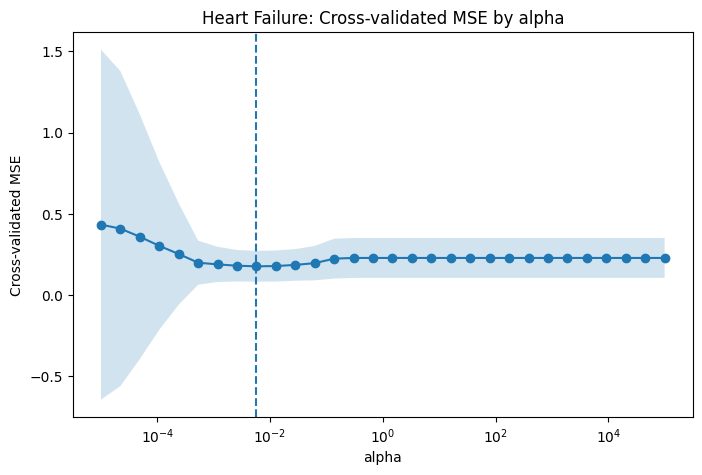

In [11]:
import matplotlib.pyplot as plt

mean_mse = lasso_cv.mse_path_.mean(axis=1)
std_mse = lasso_cv.mse_path_.std(axis=1)

plt.figure(figsize=(8,5))
plt.semilogx(lasso_cv.alphas_, mean_mse, marker='o')
plt.fill_between(lasso_cv.alphas_, mean_mse - std_mse, mean_mse + std_mse, alpha=0.2)
plt.axvline(lasso_cv.alpha_, linestyle='--')
plt.xlabel("alpha")
plt.ylabel("Cross-validated MSE")
plt.title("Heart Failure: Cross-validated MSE by alpha")
plt.show()

The cross-validated MSE plot shows how prediction error varies across different values of the regularization parameter α. In this case, the MSE decreases sharply as α increases from very small values, reaches a minimum around α ≈ 0.00574, and then begins to level off and slightly increase as α becomes larger. This pattern reflects the bias-variance trade-off: when α is very small, the model is highly flexible and may overfit, resulting in higher variance and worse performance. As α increases, regularization reduces variance and improves prediction error until an optimal point is reached. Beyond this point, further increases in α introduce too much bias, causing performance to plateau or slightly worsen. The selected α therefore represents the best balance between model flexibility and stability.

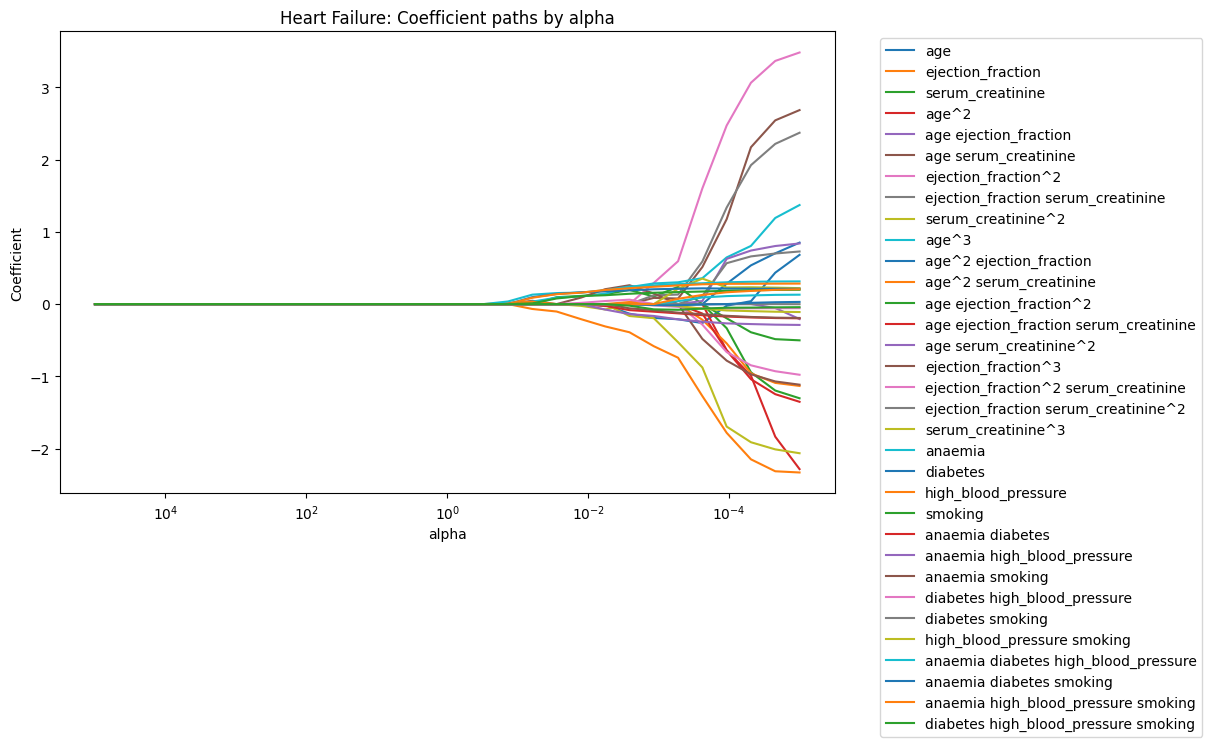

In [12]:
from sklearn.linear_model import lasso_path

alphas_path, coefs_path, _ = lasso_path(X, y, alphas=alphas, max_iter=500000)

plt.figure(figsize=(10,6))
for i, name in enumerate(feature_names):
    plt.semilogx(alphas_path, coefs_path[i], label=name)

plt.gca().invert_xaxis()
plt.xlabel("alpha")
plt.ylabel("Coefficient")
plt.title("Heart Failure: Coefficient paths by alpha")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

The coefficient path plot shows how each predictor’s coefficient changes as the regularization parameter α varies. As α increases, all coefficients shrink toward zero, with many becoming exactly zero at higher levels of regularization. In this plot, a large number of features are driven to zero relatively quickly, indicating that they contribute less to the model and are removed by LASSO. In contrast, a smaller set of variables, particularly certain higher-order terms such as ejection_fraction², ejection_fraction × serum_creatinine, and age³, maintain nonzero coefficients across a wider range of α values, suggesting that they carry more stable predictive information. Overall, the plot highlights how LASSO performs variable selection by progressively shrinking and eliminating less important predictors as the penalty increases.

In [13]:
selected = lasso_coefs[lasso_coefs != 0]
zeroed = lasso_coefs[lasso_coefs == 0]

prop_zero = (lasso_coefs == 0).mean()

print("Selected features:")
print(selected)

print("\nProportion set to zero:", prop_zero)

Selected features:
ejection_fraction                      -0.329656
serum_creatinine                        0.116875
age^3                                   0.117992
ejection_fraction^3                     0.204822
ejection_fraction^2 serum_creatinine    0.032801
serum_creatinine^3                     -0.043266
anaemia                                 0.014178
diabetes                                0.000607
high_blood_pressure                     0.013608
diabetes high_blood_pressure            0.053968
diabetes smoking                        0.003466
high_blood_pressure smoking             0.017805
dtype: float64

Proportion set to zero: 0.6363636363636364


The features selected by LASSO (those with nonzero coefficients) include ejection_fraction, serum_creatinine, age³, ejection_fraction³, ejection_fraction² × serum_creatinine, serum_creatinine³, anaemia, diabetes, high_blood_pressure, diabetes × high_blood_pressure, diabetes × smoking, and high_blood_pressure × smoking. This means that 12 features were retained in the final model, while the remaining predictors were set equal to zero. Overall, approximately 63.6% of the coefficients were eliminated, demonstrating that LASSO produces a much sparser model by removing a large number of less important or redundant variables.

In [14]:
compare = pd.DataFrame({
    "LinearRegression": linreg_coefs,
    "LASSO": lasso_coefs
})

compare["Magnitude_Increased"] = np.abs(compare["LASSO"]) > np.abs(compare["LinearRegression"])
compare["Sign_Changed"] = np.sign(compare["LASSO"]) != np.sign(compare["LinearRegression"])

print(compare)

                                        LinearRegression     LASSO  \
age                                             1.549928 -0.000000   
ejection_fraction                              -2.025371 -0.329656   
serum_creatinine                               -0.739027  0.116875   
age^2                                          -3.547991  0.000000   
age ejection_fraction                          -0.861860 -0.000000   
age serum_creatinine                            1.680570  0.000000   
ejection_fraction^2                             3.317931  0.000000   
ejection_fraction serum_creatinine              2.604767  0.000000   
serum_creatinine^2                             -2.703084 -0.000000   
age^3                                           1.889040  0.117992   
age^2 ejection_fraction                         1.022027  0.000000   
age^2 serum_creatinine                         -0.672141  0.000000   
age ejection_fraction^2                         0.017577  0.000000   
age ejection_fractio

Comparing the linear regression coefficients to the LASSO coefficients, most coefficients decrease in magnitude under LASSO, which is expected due to the shrinkage effect of regularization. In fact, nearly all predictors are either reduced substantially or set exactly equal to zero. Only one coefficient, serum_creatinine³, increases slightly in magnitude under LASSO. Additionally, a large number of coefficients change sign, including key variables such as age, serum_creatinine, age², ejection_fraction², and several interaction terms, with many of these also being shrunk to zero. These widespread sign changes reflect the instability of the unregularized linear model when many correlated polynomial and interaction terms are included.

Overall, the sign patterns in the LASSO model appear more reasonable than those in the ordinary linear regression. The linear model includes a large number of predictors, which leads to high variance and makes the coefficient estimates highly sensitive to multicollinearity, resulting in many counterintuitive signs. In contrast, LASSO introduces some bias by shrinking coefficients and eliminating many predictors, but this substantially reduces variance. From the perspective of the bias-variance trade-off, the LASSO model achieves a better balance, producing a more stable and interpretable set of coefficients that are less influenced by noise and redundancy in the data.

**Q4.** To better understand the math of regularization, we'll solve the regularized linear model problem with a single explanatory variable. So, the model is
$$
\tilde{y}_i = \tilde{b}_0 + \tilde{b}_1 \tilde{x}_i,
$$
where
$$
\tilde{y}_i = y_i - \bar{y} \quad \text{ and } \quad \tilde{x}_i = x_i - \bar{x}.
$$

Recall, we do this mean-normalization of $x$ and $y$, because
$$
\frac{1}{n} \sum_{i=1}^n \tilde{y} = \frac{1}{n} \sum_{i=1}^n y_i - \bar{y} = 0,
$$
and likewise for $x$. This trick makes the calculations easier and the results more easily interpretable.

1. To do ridge regression, add a penalty $+ \alpha (b_1)^2$ to mean squared error. What is the objective function for this problem?
2. Take the derivatives of your objective function with respect to $b_0$ and $b_1$. Set these equations equal to zero. Solve the two equations in two unknowns for $b_1$ and $b_0$.
3. How does increasing $\alpha$ change the slope coefficient?
4. If we instead used the LASSO/L1 penalty, $+\alpha |b_1|$, what challenge do you run into? This is conceptually difficult, but take 5 minutes and try to figure out the solution, and in particular, when is it optimal to set $b_1=0$?

** Answered by Hand and submitted scanned pdf to canvas with link*